Import libraries

In [1]:
import os
import time
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("../models", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Load binary data (train/val/test, using the validation split already prepared in Preprocessing.ipynb)

In [2]:
X_train_final = np.load("../results/X_train_binary.npy").astype("float32")
X_val = np.load("../results/X_val_binary.npy").astype("float32")
X_test = np.load("../results/X_test_binary.npy").astype("float32")

y_train_final = np.load("../results/y_train_binary.npy").astype("float32")
y_val = np.load("../results/y_val_binary.npy").astype("float32")
y_test = np.load("../results/y_test_binary.npy").astype("float32")

print("Training set  :", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Testing set   :", X_test.shape)


Training set  : (65865, 190)
Validation set: (16467, 190)
Testing set   : (175341, 190)


Compute class weights

In [3]:
class_labels = np.unique(y_train_final).astype(int)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train_final.astype(int)
)

class_weights = {
    int(label): float(weight)
    for label, weight in zip(class_labels, class_weight_values)
}

print("Class weights:", class_weights)

Class weights: {0: 1.1125844594594594, 1: 0.9081069902109472}


## Model factory

Function to build DNN models

In [4]:
def build_binary_model(
    input_dim,
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001
):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))

    for index, neurons in enumerate(hidden_layers, start=1):
        model.add(
            tf.keras.layers.Dense(
                neurons,
                activation="relu",
                name=f"dense_{index}"
            )
        )

        if use_batch_norm:
            model.add(
                tf.keras.layers.BatchNormalization(
                    name=f"batch_norm_{index}"
                )
            )

        if dropout_rate > 0:
            model.add(
                tf.keras.layers.Dropout(
                    dropout_rate,
                    name=f"dropout_{index}"
                )
            )

    model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid",
            name="output"
        )
    )

    optimizer_name = optimizer_name.lower()

    if optimizer_name == "adam":
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )

    else:
        raise ValueError(
            f"Unsupported optimizer: {optimizer_name}"
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

## Experiment function

Train and evaluate one experiment

In [5]:
experiment_results = []
experiment_histories = {}
trained_models = {}


def run_experiment(
    experiment_name,
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
):
    print("=" * 70)
    print("Running:", experiment_name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    gc.collect()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_binary_model(
        input_dim=X_train_final.shape[1],
        hidden_layers=hidden_layers,
        dropout_rate=dropout_rate,
        use_batch_norm=use_batch_norm,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate
    )

    callbacks = []

    if use_early_stopping:
        callbacks.append(
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True,
                verbose=1
            )
        )

    selected_class_weights = (
        class_weights if use_class_weights else None
    )

    start_time = time.time()

    history = model.fit(
        X_train_final,
        y_train_final,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=selected_class_weights,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    training_time = time.time() - start_time

    probabilities = model.predict(
        X_test,
        batch_size=batch_size,
        verbose=0
    ).ravel()

    predictions = (probabilities >= 0.5).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    auc = roc_auc_score(y_test, probabilities)

    result = {
        "Experiment": experiment_name,
        "Architecture": "-".join(
            map(str, hidden_layers)
        ),
        "Hidden Layers": len(hidden_layers),
        "Dropout": dropout_rate,
        "Batch Normalization": use_batch_norm,
        "Optimizer": optimizer_name,
        "Learning Rate": learning_rate,
        "Class Weights": use_class_weights,
        "Early Stopping": use_early_stopping,
        "Epochs Completed": len(history.history["loss"]),
        "Batch Size": batch_size,
        "Parameters": model.count_params(),
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1,
        "Test ROC-AUC": auc,
        "Training Time Seconds": training_time
    }

    experiment_results.append(result)
    experiment_histories[experiment_name] = history.history
    trained_models[experiment_name] = model

    print("\nResults")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"Time     : {training_time:.2f} seconds")

    return model, history, result

Experiment 1 — Baseline

In [6]:
model_1, history_1, result_1 = run_experiment(
    experiment_name="E1_Baseline",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)

Running: E1_Baseline

Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8629 - auc: 0.9484 - loss: 0.2856 - precision: 0.8988 - recall: 0.8463 - val_accuracy: 0.9055 - val_auc: 0.9778 - val_loss: 0.2018 - val_precision: 0.9668 - val_recall: 0.8578
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9228 - auc: 0.9817 - loss: 0.1758 - precision: 0.9363 - recall: 0.9226 - val_accuracy: 0.9204 - val_auc: 0.9838 - val_loss: 0.1768 - val_precision: 0.9756 - val_recall: 0.8775
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9375 - auc: 0.9860 - loss: 0.1523 - precision: 0.9471 - recall: 0.9389 - val_accuracy: 0.9345 - val_auc: 0.9863 - val_loss: 0.1624 - val_precision: 0.9735 - val_recall: 0.9058
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9433 - auc: 0.9877 - loss: 0.1410 - precision: 0.9516 - recall: 0.9450 - val_accuracy: 0.9426 - val_auc: 0.9877 - val_loss: 0.1519 - val_precision: 0.9730 - val_recall: 0.9214
Epoch 5/30

Experiment 2 — Network depth

Tested in isolation against the baseline (2 hidden layers): 1, 3, and 4 hidden layers, keeping every other factor at baseline defaults. The best depth found here is carried into Experiment 10 only.

In [7]:
depth_candidates = [(128,), (128, 64, 32), (128, 64, 32, 16)]
depth_runs = [{"layers": (128, 64), "result": result_1}]  # baseline = 2 layers

for layers in depth_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E2_Depth_{len(layers)}L",
        hidden_layers=layers,
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    depth_runs.append({"layers": layers, "result": res})

best_depth_run = max(depth_runs, key=lambda r: r["result"]["Test F1"])
print("Best depth found:", best_depth_run["layers"], "F1 =", best_depth_run["result"]["Test F1"])


Running: E2_Depth_1L
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8251 - auc: 0.9212 - loss: 0.3557 - precision: 0.8670 - recall: 0.8061 - val_accuracy: 0.8604 - val_auc: 0.9588 - val_loss: 0.2602 - val_precision: 0.9276 - val_recall: 0.8096
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8924 - auc: 0.9680 - loss: 0.2317 - precision: 0.9206 - recall: 0.8806 - val_accuracy: 0.8907 - val_auc: 0.9730 - val_loss: 0.2217 - val_precision: 0.9522 - val_recall: 0.8438
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9144 - auc: 0.9784 - loss: 0.2009 - precision: 0.9334 - recall: 0.9094 - val_accuracy: 0.9070 - val_auc: 0.9788 - val_loss: 0.2024 - val_precision: 0.9622 - val_recall: 0.8651
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9264 - auc: 0.9825 - loss: 0.1817 - precision: 0.9395 - recall: 0.9259 - val_accuracy: 0.9146 - val_auc: 0.9816 - val_loss: 0.1901 - val_precision: 0.9655 - val_recall: 0.8761
Epoch 5/30


Experiment 3 — Layer width

Tested in isolation against the baseline (128, 64): narrower and wider 2-layer variants from 32 up to 512 neurons per layer, keeping every other factor at baseline defaults.

In [8]:
width_candidates = [(32, 16), (64, 32), (256, 128), (512, 256)]
width_runs = [{"layers": (128, 64), "result": result_1}]  # baseline width

for layers in width_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E3_Width_{'-'.join(map(str, layers))}",
        hidden_layers=layers,
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    width_runs.append({"layers": layers, "result": res})

best_width_run = max(width_runs, key=lambda r: r["result"]["Test F1"])
print("Best width found:", best_width_run["layers"], "F1 =", best_width_run["result"]["Test F1"])

# Whichever of the depth or width search produced the better architecture
# is what Experiment 10 will build on.
best_architecture = (
    best_depth_run["layers"]
    if best_depth_run["result"]["Test F1"] >= best_width_run["result"]["Test F1"]
    else best_width_run["layers"]
)
print("\nArchitecture carried into Experiment 10:", best_architecture)


Running: E3_Width_32-16
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8122 - auc: 0.9092 - loss: 0.4006 - precision: 0.8706 - recall: 0.7739 - val_accuracy: 0.8711 - val_auc: 0.9632 - val_loss: 0.2478 - val_precision: 0.9309 - val_recall: 0.8274
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9023 - auc: 0.9735 - loss: 0.2139 - precision: 0.9220 - recall: 0.8987 - val_accuracy: 0.9041 - val_auc: 0.9778 - val_loss: 0.2045 - val_precision: 0.9641 - val_recall: 0.8578
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step - accuracy: 0.9246 - auc: 0.9819 - loss: 0.1805 - precision: 0.9384 - recall: 0.9236 - val_accuracy: 0.9236 - val_auc: 0.9827 - val_loss: 0.1802 - val_precision: 0.9630 - val_recall: 0.8957
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9343 - auc: 0.9849 - loss: 0.1632 - precision: 0.9445 - recall: 0.9356 - val_accuracy: 0.9349 - val_auc: 0.9850 - val_loss: 0.1668 - val_precision: 0.9620 - val_recall: 0.9181
Epoch 

Experiment 4 — Dropout

Dropout rates tested in isolation against the baseline architecture (128, 64).

In [9]:
dropout_candidates = [0.2, 0.3, 0.4, 0.5]
dropout_runs = []

for rate in dropout_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E4_Dropout_{rate}",
        hidden_layers=(128, 64),
        dropout_rate=rate,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    dropout_runs.append({"rate": rate, "result": res})

best_dropout_run = max(dropout_runs, key=lambda r: r["result"]["Test F1"])
best_dropout = best_dropout_run["rate"]
print("Best dropout rate found:", best_dropout, "F1 =", best_dropout_run["result"]["Test F1"])


Running: E4_Dropout_0.2
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8439 - auc: 0.9391 - loss: 0.3001 - precision: 0.8717 - recall: 0.8402 - val_accuracy: 0.9110 - val_auc: 0.9785 - val_loss: 0.1980 - val_precision: 0.9520 - val_recall: 0.8829
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9142 - auc: 0.9787 - loss: 0.1837 - precision: 0.9299 - recall: 0.9131 - val_accuracy: 0.9351 - val_auc: 0.9860 - val_loss: 0.1619 - val_precision: 0.9627 - val_recall: 0.9177
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9336 - auc: 0.9849 - loss: 0.1560 - precision: 0.9437 - recall: 0.9351 - val_accuracy: 0.9438 - val_auc: 0.9881 - val_loss: 0.1461 - val_precision: 0.9678 - val_recall: 0.9288
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9421 - auc: 0.9875 - loss: 0.1410 - precision: 0.9514 - recall: 0.9431 - val_accuracy: 0.9486 - val_auc: 0.9890 - val_loss: 0.1349 - val_precision: 0.9565 - val_recall: 0.9499
Epoch 5/

Experiment 5 — Batch normalization

Tested in isolation against the baseline (no batch norm).

In [10]:
_, _, result_5 = run_experiment(
    experiment_name="E5_BatchNorm",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=True,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)

best_use_batch_norm = result_5["Test F1"] >= result_1["Test F1"]
print("Batch norm improves F1 over baseline:", best_use_batch_norm)


Running: E5_BatchNorm
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9004 - auc: 0.9730 - loss: 0.2035 - precision: 0.9284 - recall: 0.8875 - val_accuracy: 0.8537 - val_auc: 0.9815 - val_loss: 0.3491 - val_precision: 0.7960 - val_recall: 0.9873
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9392 - auc: 0.9863 - loss: 0.1482 - precision: 0.9502 - recall: 0.9388 - val_accuracy: 0.9093 - val_auc: 0.9808 - val_loss: 0.1796 - val_precision: 0.9131 - val_recall: 0.9231
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9476 - auc: 0.9889 - loss: 0.1323 - precision: 0.9575 - recall: 0.9468 - val_accuracy: 0.9450 - val_auc: 0.9886 - val_loss: 0.1363 - val_precision: 0.9570 - val_recall: 0.9425
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9511 - auc: 0.9904 - loss: 0.1224 - precision: 0.9595 - recall: 0.9514 - val_accuracy: 0.9523 - val_auc: 0.9902 - val_loss: 0.1249 - val_precision: 0.9563 - val_recall: 0.9571
Epoch 5/30

Experiment 6 — Learning rate

Rates tested in isolation against the baseline architecture (128, 64) with Adam.

In [11]:
lr_candidates = [1e-2, 1e-4, 1e-5]
lr_runs = [{"lr": 0.001, "result": result_1}]  # baseline learning rate

for lr in lr_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E6_LR_{lr}",
        hidden_layers=(128, 64),
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name="adam",
        learning_rate=lr,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    lr_runs.append({"lr": lr, "result": res})

best_lr_run = max(lr_runs, key=lambda r: r["result"]["Test F1"])
best_lr = best_lr_run["lr"]
print("Best learning rate found:", best_lr, "F1 =", best_lr_run["result"]["Test F1"])


Running: E6_LR_0.01
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9038 - auc: 0.9740 - loss: 0.1990 - precision: 0.9218 - recall: 0.9018 - val_accuracy: 0.9340 - val_auc: 0.9862 - val_loss: 0.1581 - val_precision: 0.9738 - val_recall: 0.9046
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9437 - auc: 0.9881 - loss: 0.1348 - precision: 0.9541 - recall: 0.9431 - val_accuracy: 0.9449 - val_auc: 0.9895 - val_loss: 0.1385 - val_precision: 0.9805 - val_recall: 0.9183
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9496 - auc: 0.9900 - loss: 0.1230 - precision: 0.9597 - recall: 0.9484 - val_accuracy: 0.9324 - val_auc: 0.9907 - val_loss: 0.1532 - val_precision: 0.9889 - val_recall: 0.8872
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9514 - auc: 0.9906 - loss: 0.1190 - precision: 0.9617 - recall: 0.9496 - val_accuracy: 0.9422 - val_auc: 0.9913 - val_loss: 0.1362 - val_precision: 0.9853 - val_recall: 0.9087
Epoch 5/30
2

Experiment 7 — Optimizer

Compared in isolation against the baseline architecture (128, 64) and baseline learning rate (Adam is the baseline itself).

In [12]:
optimizer_candidates = ["rmsprop", "sgd"]
optimizer_runs = [{"optimizer": "adam", "result": result_1}]  # baseline optimizer

for opt in optimizer_candidates:
    _, _, res = run_experiment(
        experiment_name=f"E7_Optimizer_{opt}",
        hidden_layers=(128, 64),
        dropout_rate=0.0,
        use_batch_norm=False,
        optimizer_name=opt,
        learning_rate=0.001,
        use_class_weights=False,
        use_early_stopping=False,
        epochs=30,
        batch_size=256
    )
    optimizer_runs.append({"optimizer": opt, "result": res})

best_optimizer_run = max(optimizer_runs, key=lambda r: r["result"]["Test F1"])
best_optimizer = best_optimizer_run["optimizer"]
print("Best optimizer found:", best_optimizer, "F1 =", best_optimizer_run["result"]["Test F1"])


Running: E7_Optimizer_rmsprop
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8538 - auc: 0.9457 - loss: 0.2887 - precision: 0.8855 - recall: 0.8435 - val_accuracy: 0.8778 - val_auc: 0.9716 - val_loss: 0.2254 - val_precision: 0.9685 - val_recall: 0.8042
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9051 - auc: 0.9755 - loss: 0.1973 - precision: 0.9236 - recall: 0.9024 - val_accuracy: 0.8895 - val_auc: 0.9793 - val_loss: 0.2123 - val_precision: 0.9762 - val_recall: 0.8193
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9232 - auc: 0.9817 - loss: 0.1722 - precision: 0.9355 - recall: 0.9241 - val_accuracy: 0.8935 - val_auc: 0.9820 - val_loss: 0.2139 - val_precision: 0.9788 - val_recall: 0.8244
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9320 - auc: 0.9844 - loss: 0.1583 - precision: 0.9421 - recall: 0.9340 - val_accuracy: 0.8980 - val_auc: 0.9836 - val_loss: 0.2136 - val_precision: 0.9825 - val_recall: 0.8296
Ep

Experiment 8 — Class weights

Tested in isolation against the baseline (no class weighting).

In [13]:
_, _, result_8 = run_experiment(
    experiment_name="E8_ClassWeights",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=True,
    use_early_stopping=False,
    epochs=30,
    batch_size=256
)

best_use_class_weights = result_8["Test F1"] >= result_1["Test F1"]
print("Class weighting improves F1 over baseline:", best_use_class_weights)


Running: E8_ClassWeights
Epoch 1/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8595 - auc: 0.9479 - loss: 0.2854 - precision: 0.9318 - recall: 0.8037 - val_accuracy: 0.8935 - val_auc: 0.9779 - val_loss: 0.2068 - val_precision: 0.9821 - val_recall: 0.8217
Epoch 2/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9226 - auc: 0.9820 - loss: 0.1740 - precision: 0.9548 - recall: 0.9021 - val_accuracy: 0.9138 - val_auc: 0.9840 - val_loss: 0.1866 - val_precision: 0.9875 - val_recall: 0.8542
Epoch 3/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9372 - auc: 0.9861 - loss: 0.1508 - precision: 0.9590 - recall: 0.9256 - val_accuracy: 0.9297 - val_auc: 0.9864 - val_loss: 0.1681 - val_precision: 0.9829 - val_recall: 0.8877
Epoch 4/30
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9445 - auc: 0.9879 - loss: 0.1392 - precision: 0.9621 - recall: 0.9361 - val_accuracy: 0.9395 - val_auc: 0.9877 - val_loss: 0.1565 - val_precision: 0.9812 - val_recall: 0.9076
Epoch 5

Experiment 9 — Early stopping

Tested in isolation against the baseline (no early stopping), patience=10 as in the proposal.

In [14]:
_, _, result_9 = run_experiment(
    experiment_name="E9_EarlyStopping",
    hidden_layers=(128, 64),
    dropout_rate=0.0,
    use_batch_norm=False,
    optimizer_name="adam",
    learning_rate=0.001,
    use_class_weights=False,
    use_early_stopping=True,
    epochs=50,
    batch_size=256
)

best_use_early_stopping = result_9["Test F1"] >= result_1["Test F1"]
print("Early stopping improves F1 over baseline:", best_use_early_stopping)


Running: E9_EarlyStopping
Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8629 - auc: 0.9484 - loss: 0.2856 - precision: 0.8988 - recall: 0.8463 - val_accuracy: 0.9055 - val_auc: 0.9778 - val_loss: 0.2018 - val_precision: 0.9668 - val_recall: 0.8578
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9228 - auc: 0.9817 - loss: 0.1758 - precision: 0.9363 - recall: 0.9226 - val_accuracy: 0.9204 - val_auc: 0.9838 - val_loss: 0.1768 - val_precision: 0.9756 - val_recall: 0.8775
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9375 - auc: 0.9860 - loss: 0.1523 - precision: 0.9471 - recall: 0.9389 - val_accuracy: 0.9345 - val_auc: 0.9863 - val_loss: 0.1624 - val_precision: 0.9735 - val_recall: 0.9058
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9433 - auc: 0.9877 - loss: 0.1410 - precision: 0.9516 - recall: 0.9450 - val_accuracy: 0.9426 - val_auc: 0.9877 - val_loss: 0.1519 - val_precision: 0.9730 - val_recall: 0.9214
Epoch 

Experiment 10 — Final optimized model

Combines the single best value found for every factor in Experiments 2–9 (this is the only experiment where factors are combined).

In [15]:
model_10, history_10, result_10 = run_experiment(
    experiment_name="E10_Final_Optimized",
    hidden_layers=best_architecture,
    dropout_rate=best_dropout,
    use_batch_norm=best_use_batch_norm,
    optimizer_name=best_optimizer,
    learning_rate=best_lr,
    use_class_weights=best_use_class_weights,
    use_early_stopping=best_use_early_stopping,
    epochs=100,
    batch_size=256
)

print("\nFinal configuration:")
print("  Architecture      :", best_architecture)
print("  Dropout            :", best_dropout)
print("  Batch normalization:", best_use_batch_norm)
print("  Learning rate      :", best_lr)
print("  Optimizer          :", best_optimizer)
print("  Class weights      :", best_use_class_weights)
print("  Early stopping     :", best_use_early_stopping)


Running: E10_Final_Optimized
Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - auc: 0.9467 - loss: 0.2775 - precision: 0.8791 - recall: 0.8513 - val_accuracy: 0.9054 - val_auc: 0.9777 - val_loss: 0.1956 - val_precision: 0.9596 - val_recall: 0.8646
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9177 - auc: 0.9796 - loss: 0.1784 - precision: 0.9326 - recall: 0.9168 - val_accuracy: 0.9332 - val_auc: 0.9861 - val_loss: 0.1594 - val_precision: 0.9660 - val_recall: 0.9108
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9362 - auc: 0.9857 - loss: 0.1504 - precision: 0.9469 - recall: 0.9366 - val_accuracy: 0.9438 - val_auc: 0.9877 - val_loss: 0.1440 - val_precision: 0.9637 - val_recall: 0.9331
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9433 - auc: 0.9881 - loss: 0.1362 - precision: 0.9535 - recall: 0.9430 - val_accuracy: 0.9455 - val_auc: 0.9888 - val_loss: 0.1367 - val_precision: 0.9709 - val_recall: 0.9288

## Compare all experiments
Results table

In [16]:
results_df = pd.DataFrame(experiment_results)

results_df = results_df.sort_values(
    by="Test F1",
    ascending=False
).reset_index(drop=True)

results_df

,Experiment,Architecture,Hidden Layers,Dropout,Batch Normalization,Optimizer,Learning Rate,Class Weights,Early Stopping,Epochs Completed,Batch Size,Parameters,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time Seconds
0,E3_Width_256-128,256-128,2,0.0,False,adam,0.00100,False,False,30,256,81921,0.895381,0.987132,0.857467,0.917742,0.984198,14.688454
1,E1_Baseline,128-64,2,0.0,False,adam,0.00100,False,False,30,256,32769,0.892284,0.986630,0.853303,0.915136,0.983712,11.665092
2,E2_Depth_4L,128-64-32-16,4,0.0,False,adam,0.00100,False,False,30,256,35329,0.892273,0.986856,0.853085,0.915108,0.983035,12.012380
3,E9_EarlyStopping,128-64,2,0.0,False,adam,0.00100,False,True,50,256,32769,0.890847,0.987023,0.850814,0.913871,0.983216,22.164379
4,E3_Width_512-256,512-256,2,0.0,False,adam,0.00100,False,False,30,256,229377,0.890425,0.986691,0.850479,0.913536,0.982230,28.830830
5,E2_Depth_3L,128-64-32,3,0.0,False,adam,0.00100,False,False,30,256,34817,0.890328,0.985971,0.850973,0.913512,0.982344,11.992618
6,E8_ClassWeights,128-64,2,0.0,False,adam,0.00100,True,False,30,256,32769,0.889969,0.987212,0.849339,0.913100,0.983267,13.392374
7,E3_Width_64-32,64-32,2,0.0,False,adam,0.00100,False,False,30,256,14337,0.887733,0.987974,0.845342,0.911110,0.983440,9.784735
8,E6_LR_0.01,128-64,2,0.0,False,adam,0.01000,False,False,30,256,32769,0.886746,0.987762,0.844060,0.910275,0.981398,11.635225
9,E4_Dropout_0.3,128-64,2,0.3,False,adam,0.00100,False,False,30,256,32769,0.882469,0.988743,0.836846,0.906475,0.982381,13.469647


Save results

In [17]:
results_df.to_csv(
    "../results/binary_optimization_results.csv",
    index=False
)

print("Optimization results saved.")

Optimization results saved.


Show important metrics

In [18]:
results_df[
    [
        "Experiment",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC",
        "Training Time Seconds"
    ]
]

,Experiment,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time Seconds
0,E3_Width_256-128,0.895381,0.987132,0.857467,0.917742,0.984198,14.688454
1,E1_Baseline,0.892284,0.986630,0.853303,0.915136,0.983712,11.665092
2,E2_Depth_4L,0.892273,0.986856,0.853085,0.915108,0.983035,12.012380
3,E9_EarlyStopping,0.890847,0.987023,0.850814,0.913871,0.983216,22.164379
4,E3_Width_512-256,0.890425,0.986691,0.850479,0.913536,0.982230,28.830830
5,E2_Depth_3L,0.890328,0.985971,0.850973,0.913512,0.982344,11.992618
6,E8_ClassWeights,0.889969,0.987212,0.849339,0.913100,0.983267,13.392374
7,E3_Width_64-32,0.887733,0.987974,0.845342,0.911110,0.983440,9.784735
8,E6_LR_0.01,0.886746,0.987762,0.844060,0.910275,0.981398,11.635225
9,E4_Dropout_0.3,0.882469,0.988743,0.836846,0.906475,0.982381,13.469647


## Plot experiment comparison
F1-score comparison

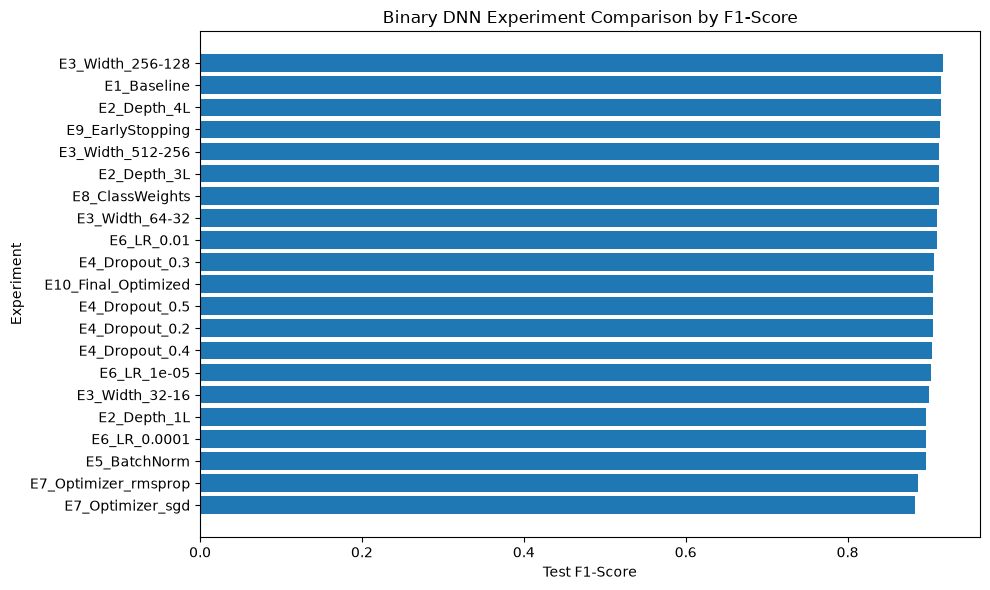

In [19]:
plot_df = results_df.sort_values(
    "Test F1",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Experiment"],
    plot_df["Test F1"]
)

plt.title("Binary DNN Experiment Comparison by F1-Score")
plt.xlabel("Test F1-Score")
plt.ylabel("Experiment")
plt.tight_layout()

plt.savefig(
    "../figures/binary_experiment_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Recall comparison

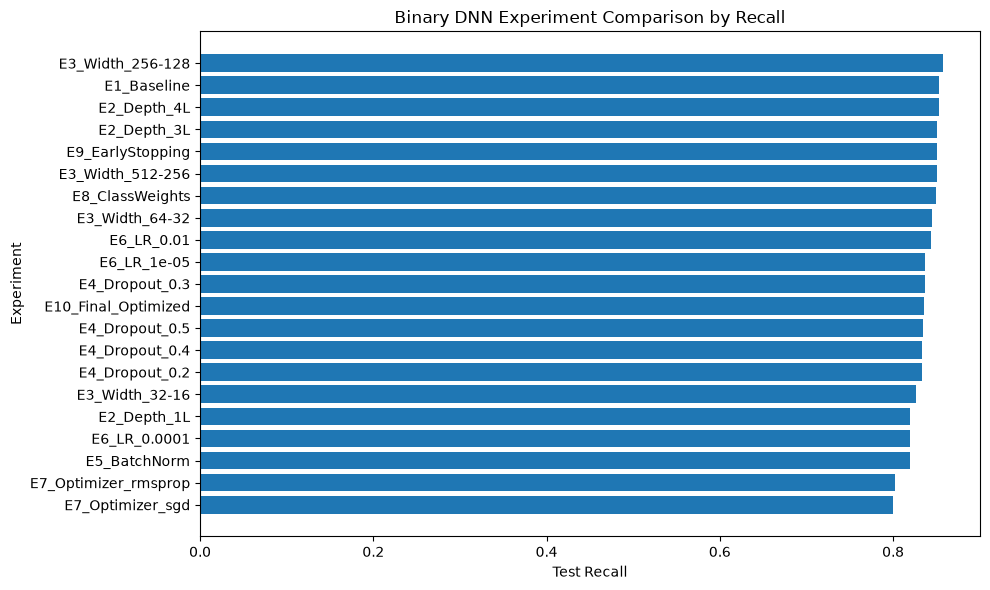

In [20]:
plot_df = results_df.sort_values(
    "Test Recall",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Experiment"],
    plot_df["Test Recall"]
)

plt.title("Binary DNN Experiment Comparison by Recall")
plt.xlabel("Test Recall")
plt.ylabel("Experiment")
plt.tight_layout()

plt.savefig(
    "../figures/binary_experiment_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Accuracy, precision, recall and F1

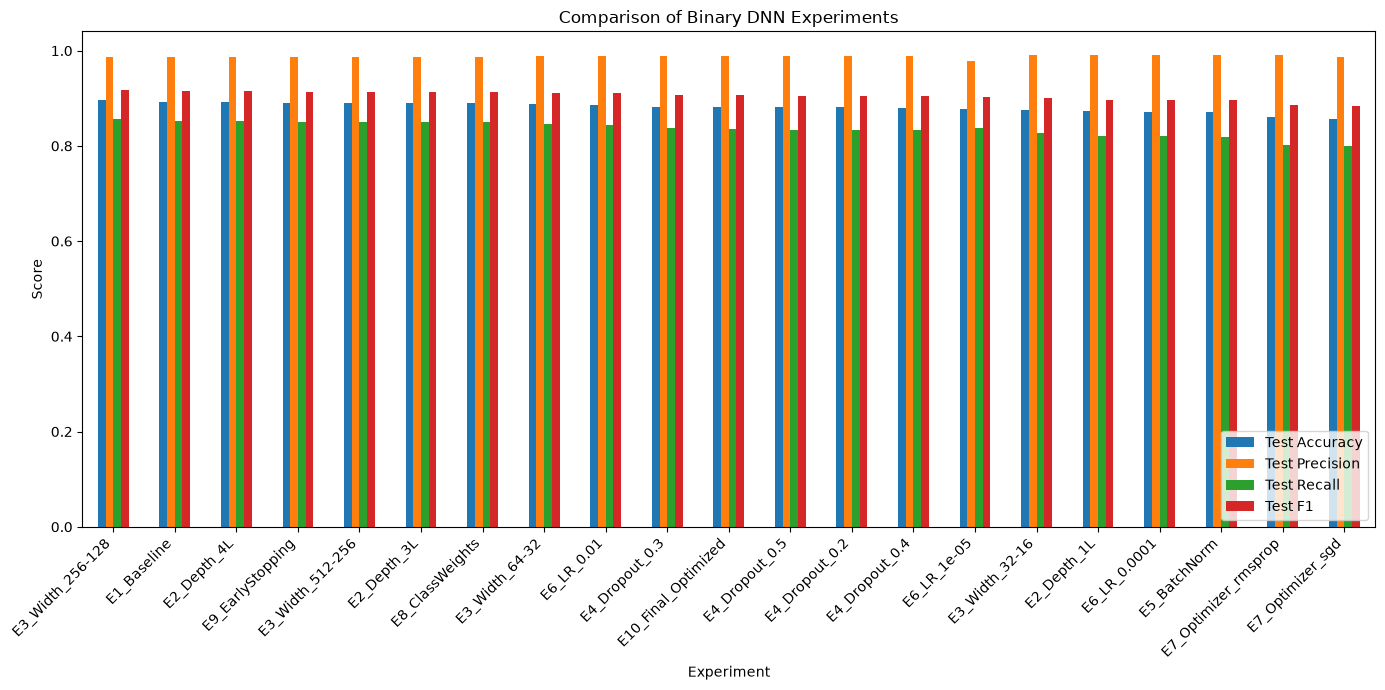

In [21]:
metrics_df = results_df.set_index("Experiment")[
    [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
]

metrics_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Comparison of Binary DNN Experiments")
plt.xlabel("Experiment")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(
    "../figures/binary_all_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Select the best model

In [22]:
best_experiment_name = results_df.iloc[0]["Experiment"]

print("Best experiment:", best_experiment_name)
print()
print(results_df.iloc[0])

Best experiment: E3_Width_256-128

Experiment               E3_Width_256-128
Architecture                      256-128
Hidden Layers                           2
Dropout                               0.0
Batch Normalization                 False
Optimizer                            adam
Learning Rate                       0.001
Class Weights                       False
Early Stopping                      False
Epochs Completed                       30
Batch Size                            256
Parameters                          81921
Test Accuracy                    0.895381
Test Precision                   0.987132
Test Recall                      0.857467
Test F1                          0.917742
Test ROC-AUC                     0.984198
Training Time Seconds           14.688454
Name: 0, dtype: object


In [23]:
best_model = trained_models[best_experiment_name]

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,765 (960.02 KB)

 Trainable params: 81,921 (320.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 163,844 (640.02 KB)

In [24]:
best_model.save(
    "../models/binary_optimized_best.keras"
)

print("Best optimized model saved successfully.")

Best optimized model saved successfully.


Best-model classification report

In [25]:
best_probabilities = best_model.predict(
    X_test,
    batch_size=256,
    verbose=0
).ravel()

best_predictions = (
    best_probabilities >= 0.5
).astype(int)

best_report = classification_report(
    y_test,
    best_predictions,
    target_names=["Normal", "Attack"],
    digits=4,
    zero_division=0
)

print(best_report)

              precision    recall  f1-score   support

      Normal     0.7627    0.9762    0.8563     56000
      Attack     0.9871    0.8575    0.9177    119341

    accuracy                         0.8954    175341
   macro avg     0.8749    0.9168    0.8870    175341
weighted avg     0.9154    0.8954    0.8981    175341



Save classification report

In [26]:
best_report_df = pd.DataFrame(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Normal", "Attack"],
        output_dict=True,
        zero_division=0
    )
).transpose()

best_report_df.to_csv(
    "../results/binary_optimized_classification_report.csv"
)

best_report_df

,precision,recall,f1-score,support
Normal,0.762682,0.976179,0.856324,56000.000000
Attack,0.987132,0.857467,0.917742,119341.000000
accuracy,0.895381,0.895381,0.895381,0.895381
macro avg,0.874907,0.916823,0.887033,175341.000000
weighted avg,0.915447,0.895381,0.898126,175341.000000


Confusion matrix

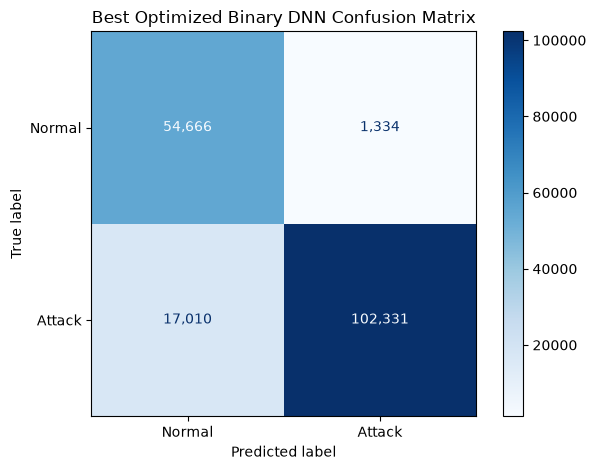

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

best_confusion_matrix = confusion_matrix(
    y_test,
    best_predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=best_confusion_matrix,
    display_labels=["Normal", "Attack"]
)

display_matrix.plot(
    values_format=",",
    cmap="Blues"
)

plt.title("Best Optimized Binary DNN Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../figures/binary_optimized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Plot best training history

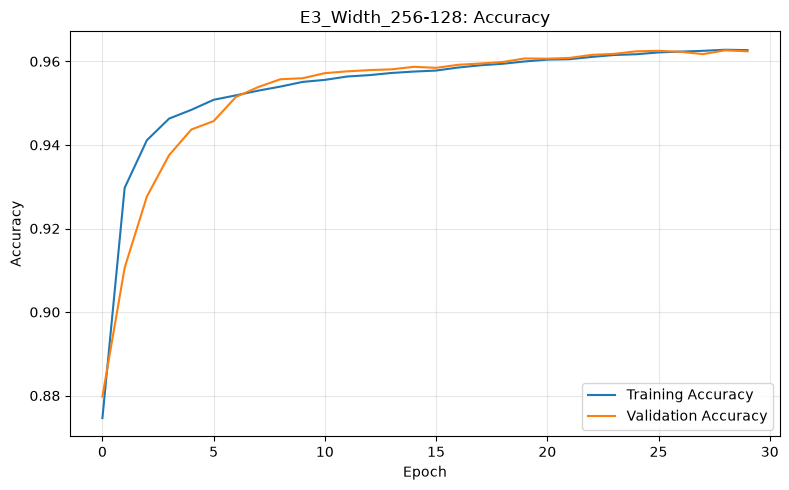

In [28]:
best_history = experiment_histories[
    best_experiment_name
]

plt.figure(figsize=(8, 5))

plt.plot(
    best_history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    best_history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    f"{best_experiment_name}: Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/binary_optimized_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Best-model loss

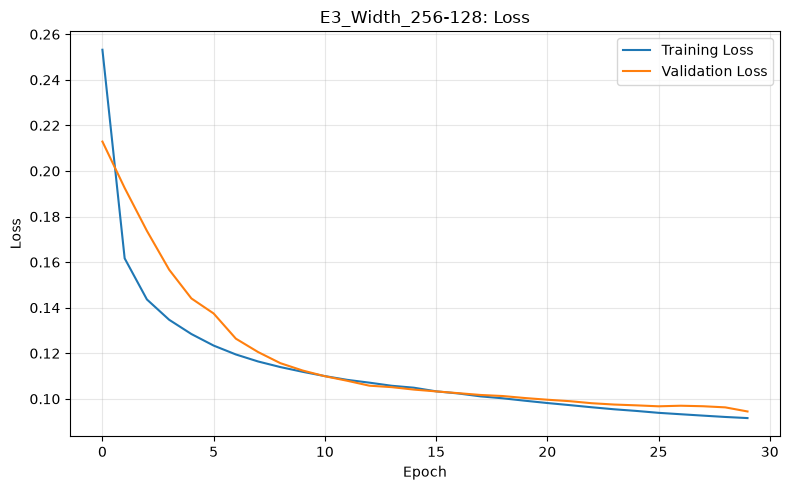

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    best_history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history["val_loss"],
    label="Validation Loss"
)

plt.title(
    f"{best_experiment_name}: Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/binary_optimized_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()